# False Positive Socket and Neighborhood Investigation

This notebook investigates what false positives (FP) are made of for one model run, with emphasis on FP-enriched destination socket classes and temporal neighborhood size. The same cells can be rerun for another model, e.g. M2, to compare whether the failure mode improves.


## 1. Configuration

Set the prediction folder/model name for the model you want to inspect. For M2, duplicate this notebook or change only this cell.


In [1]:
import os
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#matplotlib inline

PROJECT_ROOT = Path('/work3/s253892/ProvIDS/')
SRC_DIR = PROJECT_ROOT / 'src'
DATA_DIR = PROJECT_ROOT / 'DATA/DATA'
GROUND_TRUTH_DIR = PROJECT_ROOT / 'darpa_labelling' / 'groundtruth'

# prediction_folder = PROJECT_ROOT / 'ablations/m_variation_ablations/tgn_nomem/3L/TGN/ckpt'
prediction_folder = PROJECT_ROOT / 'ablations/m_variation_ablations/tgn/2L_sum/TGN/ckpt' 
prediction_folder = PROJECT_ROOT / 'ablations/m_variation_ablations/m2/2L_mean/TGN/ckpt'
model_name = 'TGN-m2'
conf_id = '0'
n_seeds = 3

dataset = 'THEIA'
dataset_name = 'darpa_theia_0to25'
dataset_path = DATA_DIR / dataset_name

print(model_name)
print(dataset_path)


TGN-m2
/work3/s253892/ProvIDS/DATA/DATA/darpa_theia_0to25


## 2. Load Graph Data, Ground Truth, and Predictions


In [2]:
nodes = pd.read_csv(dataset_path / 'attributed_nodes.csv', low_memory=False)
if 'Unnamed: 0' in nodes.columns:
    nodes = nodes.drop(columns=['Unnamed: 0'])

edges = pd.read_csv(dataset_path / 'edges.csv')

if dataset == 'TRACE':
    split = '0to210'
    attack_files = [
        'TC3_trace_firefox_backdoor_final_aggregated.csv',
        'TC3_trace_browser_extension_final_aggregated.csv',
        'TC3_trace_pine_phishing_exe_final_aggregated.csv',
        'TC3_trace_thunderbird_phishing_exe_final_aggregated.csv',
    ]
elif dataset == 'THEIA':
    split = '0to25'
    attack_files = [
        'TC3_theia_firefox_backdoor_final_aggregated.csv',
        'TC3_theia_browser_extension_final_aggregated.csv',
    ]
else:
    raise NotImplementedError(dataset)

attacks = pd.concat([pd.read_csv(GROUND_TRUTH_DIR / f) for f in attack_files])
edges['malicious'] = edges.hash_id.isin(attacks.edge_hash_id)

aggregated_predictions = 0
for seed in range(n_seeds):
    prediction_path = prediction_folder / f'split_conf_{conf_id}_detection_results-{split}_seed_{seed}.csv'
    predictions = pd.read_csv(prediction_path)
    aggregated_predictions += predictions.prob.values
aggregated_predictions /= n_seeds

n_train_edges = int((edges.ext_roll == 0).sum())
n_test_edges = int((edges.ext_roll == 2).sum())
assert len(aggregated_predictions) == n_test_edges, (len(aggregated_predictions), n_test_edges)

print(f'edges: {len(edges):,}')
print(f'train edges: {n_train_edges:,}')
print(f'test edges: {n_test_edges:,}')
print(f'malicious test edges: {edges.loc[edges.ext_roll == 2, "malicious"].sum():,}')


edges: 8,416,187
train edges: 3,079,695
test edges: 4,673,737
malicious test edges: 211


## 3. Join Node Attributes and Build TP/FP/FN/TN Splits

`pred_anomalous=True` means the model predicted the edge as anomalous.


In [3]:
NODE_ATTR_COLS = [
    'type', 'exe', 'private', 'port', 'port_class', 'ip',
    'extension', 'root', 'name', 'pid', 'args'
]
NODE_ATTR_COLS = [col for col in NODE_ATTR_COLS if col in nodes.columns]


def attach_node_attrs(edge_df):
    edge_df = edge_df.copy()
    src_attrs = nodes.iloc[edge_df.src.to_numpy()][NODE_ATTR_COLS].reset_index(drop=True).add_suffix('_src')
    dst_attrs = nodes.iloc[edge_df.dst.to_numpy()][NODE_ATTR_COLS].reset_index(drop=True).add_suffix('_dst')
    edge_df = edge_df.reset_index(drop=False).rename(columns={'index': 'edge_index'})
    return pd.concat([edge_df, src_attrs, dst_attrs], axis=1)

pred_anomalous_values = ~aggregated_predictions.round().astype(bool)
test_mask = edges.ext_roll == 2
test_index = edges.index[test_mask]
pred_anomalous = pd.Series(pred_anomalous_values, index=test_index)
malicious_test = edges.loc[test_mask, 'malicious']

fp_idx = test_index[pred_anomalous & (~malicious_test)]
tn_idx = test_index[(~pred_anomalous) & (~malicious_test)]
tp_idx = test_index[pred_anomalous & malicious_test]
fn_idx = test_index[(~pred_anomalous) & malicious_test]
train_idx = edges.index[edges.ext_roll == 0]

# Attach attributes only after splitting. This avoids duplicating node attributes on the full edge table.
fp = attach_node_attrs(edges.loc[fp_idx])
tp = attach_node_attrs(edges.loc[tp_idx])
fn = attach_node_attrs(edges.loc[fn_idx])

# TN and train are large but needed for exact percentage baselines. If memory is tight,
# set USE_EXACT_NORMAL_BASELINES=False to use deterministic samples for exploratory analysis.
USE_EXACT_NORMAL_BASELINES = True
NORMAL_SAMPLE_SIZE = 500_000

if USE_EXACT_NORMAL_BASELINES:
    tn = attach_node_attrs(edges.loc[tn_idx])
    train = attach_node_attrs(edges.loc[train_idx])
else:
    tn_sample_idx = pd.Series(tn_idx).sample(min(NORMAL_SAMPLE_SIZE, len(tn_idx)), random_state=0).to_numpy()
    train_sample_idx = pd.Series(train_idx).sample(min(NORMAL_SAMPLE_SIZE, len(train_idx)), random_state=0).to_numpy()
    tn = attach_node_attrs(edges.loc[tn_sample_idx])
    train = attach_node_attrs(edges.loc[train_sample_idx])
    print('Using sampled TN/train baselines. Percentages are approximate.')

df_counts = pd.DataFrame({
    'count': [len(tp), len(fp), len(fn), len(tn_idx)],
}, index=['TP', 'FP', 'FN', 'TN'])
df_counts['pct_test'] = df_counts['count'] / len(test_index) * 100
df_counts

,count,pct_test
TP,57,0.001220
FP,54033,1.156098
FN,154,0.003295
TN,4619493,98.839387


In [4]:
df_counts.to_latex()

'\\begin{tabular}{lrr}\n\\toprule\n & count & pct_test \\\\\n\\midrule\nTP & 57 & 0.001220 \\\\\nFP & 54033 & 1.156098 \\\\\nFN & 154 & 0.003295 \\\\\nTN & 4619493 & 98.839387 \\\\\n\\bottomrule\n\\end{tabular}\n'

## 4. Broad FP/TN/Train Pattern Comparison

The edge pattern is `(type_src, type_dst, syscall, exe_src, exe_dst)`. This table identifies patterns that are overrepresented among FPs compared with TN and train.


In [5]:
columns_to_group = ['type_src', 'type_dst', 'syscall']

fp_counts = fp.groupby(columns_to_group, dropna=False).size()
tn_counts = tn.groupby(columns_to_group, dropna=False).size()
tp_counts = tp.groupby(columns_to_group, dropna=False).size()
fn_counts = fn.groupby(columns_to_group, dropna=False).size()  # if you have fn
train_counts = train.groupby(columns_to_group, dropna=False).size()

pattern_view = pd.DataFrame({
    'fp': fp_counts,
    'tn': tn_counts,
    'tp': tp_counts,
    'fn': fn_counts,
    'train': train_counts,
}).fillna(0)

pattern_view['test_total'] = (
    pattern_view['fp'] +
    pattern_view['tn'] +
    pattern_view['tp'] +
    pattern_view['fn']
)

pattern_view['benign_test_total'] = pattern_view['fp'] + pattern_view['tn']
pattern_view['malicious_test_total'] = pattern_view['tp'] + pattern_view['fn']

pattern_view['fp_rate_within_benign'] = (
    pattern_view['fp'] / pattern_view['benign_test_total'].replace(0, np.nan) * 100
)

pattern_view['tn_rate_within_benign'] = (
    pattern_view['tn'] / pattern_view['benign_test_total'].replace(0, np.nan) * 100
)

pattern_view['tp_rate_within_malicious'] = (
    pattern_view['tp'] / pattern_view['malicious_test_total'].replace(0, np.nan) * 100
)

pattern_view['fn_rate_within_malicious'] = (
    pattern_view['fn'] / pattern_view['malicious_test_total'].replace(0, np.nan) * 100
)

pattern_view['fp_share_of_all_fp'] = pattern_view['fp'] / len(fp) * 100
pattern_view['test_share'] = pattern_view['test_total'] / pattern_view['test_total'].sum() * 100
pattern_view['train_share'] = pattern_view['train'] / len(train) * 100


cols = [
    'fp',
    'tn',
    'test_total',
    'benign_test_total',
    'fp_rate_within_benign',
    'fp_share_of_all_fp',
    'test_share',
    'train_share',
    'tp',
    'fn',
    'tp_rate_within_malicious',
]

pattern_view[pattern_view['fp'] >= 100] \
    .sort_values('fp_rate_within_benign', ascending=False)[cols] \
    .round(2) \
    .head(20)

fp       tn  test_total  benign_test_total  \
type_src type_dst syscall                                                  
1        2        16        8336    87291     95659.0              95627   
                  9         8071   147133    155286.0             155204   
         1        2         7753   151104    158894.0             158857   
         0        6         9135   222233    231370.0             231368   
2        1        8         1418   177397    178848.0             178815   
1        0        15        7406  1039292   1046710.0            1046698   
0        1        3          403    70482     70890.0              70885   
                  14       11511  2724561   2736080.0            2736072   

                           fp_rate_within_benign  fp_share_of_all_fp  \
type_src type_dst syscall                                              
1        2        16                        8.72               15.43   
                  9                         5.20               14.94   
         1        2                         4.88               14.35   
         0        6                         3.95               16.91   
2        1        8                         0.79                2.62   
1        0        15                        0.71               13.71   
0        1        3                         0.57                0.75   
                  14                        0.42               21.30   

                           test_share  train_share    tp  fn  \
type_src type_dst syscall                                      
1        2        16             2.05         2.45   8.0  24   
                  9              3.32         3.89  41.0  41   
         1        2              3.40         1.80   0.0  37   
         0        6              4.95         5.07   0.0   2   
2        1        8              3.83         4.71   4.0  29   
1        0        15            22.40        24.39   2.0  10   
0        1        3              1.52         1.10   0.0   5   
                  14            58.54        56.59   2.0   6   

                           tp_rate_within_malicious  
type_src type_dst syscall                            
1        2        16                          25.00  
                  9                           50.00  
         1        2                            0.00  
         0        6                            0.00  
2        1        8                           12.12  
1        0        15                          16.67  
0        1        3                            0.00  
                  14                          25.00

In [6]:
import numpy as np
import pandas as pd

TYPE_MAP = {
    0: "File",
    1: "Process",
    2: "Socket",
}

SYSCALL_MAP = {
    0: "NotDefined", 1: "Vfork", 2: "Clone", 3: "Execve", 4: "Kill",
    5: "Pipe", 6: "Delete", 7: "Create", 8: "Recv", 9: "Send",
    10: "Mkdir", 11: "Rmdir", 12: "Open", 13: "Load", 14: "Read",
    15: "Write", 16: "Connect", 17: "Getpeername", 18: "Filepath",
    19: "Mode", 20: "Mtime", 21: "Linknum", 22: "Uid", 23: "Count",
    24: "Nametype", 25: "Version", 26: "Dev", 27: "SizeByte",
}

def add_labels(df):
    df = df.copy()
    df["type_src_name"] = df["type_src"].map(TYPE_MAP)
    df["type_dst_name"] = df["type_dst"].map(TYPE_MAP)
    df["syscall_name"] = df["syscall"].map(SYSCALL_MAP)
    df["interaction"] = (
        df["type_src_name"].astype(str)
        + " -> "
        + df["type_dst_name"].astype(str)
        + " / "
        + df["syscall_name"].astype(str)
    )
    return df

fp = add_labels(fp)
tn = add_labels(tn)
tp = add_labels(tp)
fn = add_labels(fn)
train = add_labels(train)

target_families = [
    (1, 2, 16),  # Process -> Socket / Connect
    (1, 2, 9),   # Process -> Socket / Send
    (1, 0, 6),   # Process -> File / Delete
    (1, 1, 2),   # Process -> Process / Clone
]

def keep_target_families(df):
    mask = False
    for type_src, type_dst, syscall in target_families:
        mask = mask | (
            (df["type_src"] == type_src)
            & (df["type_dst"] == type_dst)
            & (df["syscall"] == syscall)
        )
    return df[mask].copy()

fp_target = keep_target_families(fp)
tn_target = keep_target_families(tn)
tp_target = keep_target_families(tp)
fn_target = keep_target_families(fn)
train_target = keep_target_families(train)

In [7]:
columns_to_group = ["exe_src"]

fp_counts = fp_target.groupby(columns_to_group, dropna=False).size()
tn_counts = tn_target.groupby(columns_to_group, dropna=False).size()
tp_counts = tp_target.groupby(columns_to_group, dropna=False).size()
fn_counts = fn_target.groupby(columns_to_group, dropna=False).size()
train_counts = train_target.groupby(columns_to_group, dropna=False).size()

process_view = pd.DataFrame({
    "fp": fp_counts,
    "tn": tn_counts,
    "tp": tp_counts,
    "fn": fn_counts,
    "train": train_counts,
}).fillna(0)

process_view["test_total"] = (
    process_view["fp"] +
    process_view["tn"] +
    process_view["tp"] +
    process_view["fn"]
)

process_view["benign_test_total"] = process_view["fp"] + process_view["tn"]
process_view["malicious_test_total"] = process_view["tp"] + process_view["fn"]

process_view["fp_rate_within_benign"] = (
    process_view["fp"] / process_view["benign_test_total"].replace(0, np.nan) * 100
)

process_view["tn_rate_within_benign"] = (
    process_view["tn"] / process_view["benign_test_total"].replace(0, np.nan) * 100
)

process_view["tp_rate_within_malicious"] = (
    process_view["tp"] / process_view["malicious_test_total"].replace(0, np.nan) * 100
)

process_view["fn_rate_within_malicious"] = (
    process_view["fn"] / process_view["malicious_test_total"].replace(0, np.nan) * 100
)

process_view["fp_share_of_target_fp"] = process_view["fp"] / len(fp_target) * 100
process_view["test_share"] = process_view["test_total"] / process_view["test_total"].sum() * 100
process_view["train_share"] = process_view["train"] / len(train_target) * 100

cols = [
    "fp",
    "tn",
    "test_total",
    "benign_test_total",
    "fp_rate_within_benign",
    "fp_share_of_target_fp",
    "test_share",
    "train_share",
    "tp",
    "fn",
    "tp_rate_within_malicious",
]

process_view[process_view["fp"] >= 100] \
    .sort_values("fp_rate_within_benign", ascending=False)[cols] \
    .round(2) \
    .head(20)

,fp,tn,test_total,benign_test_total,fp_rate_within_benign,fp_share_of_target_fp,test_share,train_share,tp,fn,tp_rate_within_malicious
exe_src,,,,,,,,,,,
ubuntu-geoip-provider,290.0,89.0,379.0,379.0,76.52,0.87,0.06,0.21,0.0,0.0,NaN
sh,3314.0,5168.0,8518.0,8482.0,39.07,9.95,1.33,0.01,2.0,34.0,5.56
thunderbird,1164.0,3906.0,5070.0,5070.0,22.96,3.50,0.79,0.01,0.0,0.0,NaN
sshd,843.0,3268.0,4111.0,4111.0,20.51,2.53,0.64,0.47,0.0,0.0,NaN
NaN,232.0,1477.0,1709.0,1709.0,13.58,0.70,0.27,0.00,0.0,0.0,NaN
python,2795.0,17797.0,20592.0,20592.0,13.57,8.39,3.21,2.77,0.0,0.0,NaN
fluxbox,12214.0,125296.0,137510.0,137510.0,8.88,36.68,21.45,27.10,0.0,0.0,NaN
firefox,11544.0,330814.0,342361.0,342358.0,3.37,34.67,53.39,54.06,2.0,1.0,66.67
sshd:,461.0,20549.0,21010.0,21010.0,2.19,1.38,3.28,0.39,0.0,0.0,NaN


In [8]:
def interaction_table(fp_i, tn_i, tp_i, fn_i, train_i, columns_to_group, min_fp=100):
    fp_counts = fp_i.groupby(columns_to_group, dropna=False).size()
    tn_counts = tn_i.groupby(columns_to_group, dropna=False).size()
    tp_counts = tp_i.groupby(columns_to_group, dropna=False).size()
    fn_counts = fn_i.groupby(columns_to_group, dropna=False).size()
    train_counts = train_i.groupby(columns_to_group, dropna=False).size()

    view = pd.DataFrame({
        "fp": fp_counts,
        "tn": tn_counts,
        "tp": tp_counts,
        "fn": fn_counts,
        "train": train_counts,
    }).fillna(0)

    view["test_total"] = view["fp"] + view["tn"] + view["tp"] + view["fn"]
    view["benign_test_total"] = view["fp"] + view["tn"]
    view["malicious_test_total"] = view["tp"] + view["fn"]

    view["fp_rate_within_benign"] = (
        view["fp"] / view["benign_test_total"].replace(0, np.nan) * 100
    )

    view["tn_rate_within_benign"] = (
        view["tn"] / view["benign_test_total"].replace(0, np.nan) * 100
    )

    view["tp_rate_within_malicious"] = (
        view["tp"] / view["malicious_test_total"].replace(0, np.nan) * 100
    )

    view["fn_rate_within_malicious"] = (
        view["fn"] / view["malicious_test_total"].replace(0, np.nan) * 100
    )

    view["fp_share_within_interaction"] = view["fp"] / max(len(fp_i), 1) * 100
    view["test_share_within_interaction"] = (
        view["test_total"] / max(view["test_total"].sum(), 1) * 100
    )
    view["train_share_within_interaction"] = view["train"] / max(len(train_i), 1) * 100

    cols = [
        "fp",
        "tn",
        "test_total",
        "benign_test_total",
        "fp_rate_within_benign",
        "fp_share_within_interaction",
        "test_share_within_interaction",
        "train_share_within_interaction",
        "tp",
        "fn",
        "tp_rate_within_malicious",
    ]

    return (
        view[view["fp"] >= min_fp]
        .sort_values("fp_rate_within_benign", ascending=False)[cols]
        .round(2)
    )

def filter_interaction(df, type_src, type_dst, syscall):
    return df[
        (df["type_src"] == type_src)
        & (df["type_dst"] == type_dst)
        & (df["syscall"] == syscall)
    ].copy()

interactions = {
    "process_socket_connect": {
        "type_src": 1,
        "type_dst": 2,
        "syscall": 16,
        "group_cols": ["exe_src", "private_dst", "port_class_dst"],
    },
    "process_socket_send": {
        "type_src": 1,
        "type_dst": 2,
        "syscall": 9,
        "group_cols": ["exe_src", "private_dst", "port_class_dst"],
    },
    "process_file_delete": {
        "type_src": 1,
        "type_dst": 0,
        "syscall": 6,
        "group_cols": ["exe_src", "root_dst", "extension_dst"],
    },
    "process_process_clone": {
        "type_src": 1,
        "type_dst": 1,
        "syscall": 2,
        "group_cols": ["exe_src", "exe_dst"],
    },
    "socket_process_recv": {
        "type_src": 2,
        "type_dst": 1,
        "syscall": 8,
        "group_cols": ["private_src", "port_class_src", "exe_dst"],
    },
    "process_file_write": {
        "type_src": 1,
        "type_dst": 0,
        "syscall": 15,
        "group_cols": ["exe_src", "root_dst", "extension_dst"],
    },
    "file_process_execve": {
        "type_src": 0,
        "type_dst": 1,
        "syscall": 3,
        "group_cols": ["root_src", "extension_src", "exe_dst"],
    },
    "file_process_read": {
        "type_src": 0,
        "type_dst": 1,
        "syscall": 14,
        "group_cols": ["root_src", "extension_src", "exe_dst"],
    },
}

tables_by_interaction = {}

for name, spec in interactions.items():
    fp_i = filter_interaction(fp, spec["type_src"], spec["type_dst"], spec["syscall"])
    tn_i = filter_interaction(tn, spec["type_src"], spec["type_dst"], spec["syscall"])
    tp_i = filter_interaction(tp, spec["type_src"], spec["type_dst"], spec["syscall"])
    fn_i = filter_interaction(fn, spec["type_src"], spec["type_dst"], spec["syscall"])
    train_i = filter_interaction(train, spec["type_src"], spec["type_dst"], spec["syscall"])

    available_cols = [
        col for col in spec["group_cols"]
        if all(col in df.columns for df in [fp_i, tn_i, tp_i, fn_i, train_i])
    ]

    tables_by_interaction[name] = interaction_table(
        fp_i=fp_i,
        tn_i=tn_i,
        tp_i=tp_i,
        fn_i=fn_i,
        train_i=train_i,
        columns_to_group=available_cols,
        min_fp=100,
    )

    print("\n" + name)
    display(tables_by_interaction[name].head(15))


process_socket_connect


fp       tn  test_total  \
exe_src               private_dst port_class_dst                                
-bash                 0.0         [1.0, 12]        159.0      1.0       160.0   
sshd                  0.0         [1.0, 12]        413.0      6.0       419.0   
ubuntu-geoip-provider 0.0         [1.0, 12]        146.0      6.0       152.0   
thunderbird           0.0         [1.0, 12]        536.0    288.0       824.0   
NaN                   0.0         [1.0, 12]        109.0    214.0       323.0   
python                0.0         [1.0, 12]       1397.0   6697.0      8094.0   
firefox               2.0         [12, 6.0]        799.0  10584.0     11383.0   
                      0.0         [1.0, 12]       4684.0  63859.0     68543.0   

                                                  benign_test_total  \
exe_src               private_dst port_class_dst                      
-bash                 0.0         [1.0, 12]                   160.0   
sshd                  0.0         [1.0, 12]                   419.0   
ubuntu-geoip-provider 0.0         [1.0, 12]                   152.0   
thunderbird           0.0         [1.0, 12]                   824.0   
NaN                   0.0         [1.0, 12]                   323.0   
python                0.0         [1.0, 12]                  8094.0   
firefox               2.0         [12, 6.0]                 11383.0   
                      0.0         [1.0, 12]                 68543.0   

                                                  fp_rate_within_benign  \
exe_src               private_dst port_class_dst                          
-bash                 0.0         [1.0, 12]                       99.38   
sshd                  0.0         [1.0, 12]                       98.57   
ubuntu-geoip-provider 0.0         [1.0, 12]                       96.05   
thunderbird           0.0         [1.0, 12]                       65.05   
NaN                   0.0         [1.0, 12]                       33.75   
python                0.0         [1.0, 12]                       17.26   
firefox               2.0         [12, 6.0]                        7.02   
                      0.0         [1.0, 12]                        6.83   

                                                  fp_share_within_interaction  \
exe_src               private_dst port_class_dst                                
-bash                 0.0         [1.0, 12]                              1.91   
sshd                  0.0         [1.0, 12]                              4.95   
ubuntu-geoip-provider 0.0         [1.0, 12]                              1.75   
thunderbird           0.0         [1.0, 12]                              6.43   
NaN                   0.0         [1.0, 12]                              1.31   
python                0.0         [1.0, 12]                             16.76   
firefox               2.0         [12, 6.0]                              9.58   
                      0.0         [1.0, 12]                             56.19   

                                                  test_share_within_interaction  \
exe_src               private_dst port_class_dst                                  
-bash                 0.0         [1.0, 12]                                0.17   
sshd                  0.0         [1.0, 12]                                0.44   
ubuntu-geoip-provider 0.0         [1.0, 12]                                0.16   
thunderbird           0.0         [1.0, 12]                                0.86   
NaN                   0.0         [1.0, 12]                                0.34   
python                0.0         [1.0, 12]                                8.46   
firefox               2.0         [12, 6.0]                               11.90   
                      0.0         [1.0, 12]                               71.65   

                                                  train_share_within_interaction  \
exe_src               private_dst port_class_dst       


process_socket_send


fp       tn  test_total  \
exe_src               private_dst port_class_dst                                
-bash                 0.0         [1.0, 12]        159.0      1.0       160.0   
sshd                  0.0         [1.0, 12]        412.0      7.0       419.0   
ubuntu-geoip-provider 0.0         [1.0, 12]        144.0      7.0       151.0   
thunderbird           0.0         [1.0, 12]        536.0    288.0       824.0   
sshd:                 0.0         [11.0]           210.0    247.0       457.0   
                                  [10.0]           247.0    335.0       582.0   
NaN                   0.0         [1.0, 12]        110.0    215.0       325.0   
python                0.0         [1.0, 12]       1391.0   6703.0      8094.0   
firefox               0.0         [1.0, 12]       4654.0  63890.0     68544.0   
                                  [2.0, 12]        127.0  11389.0     11517.0   

                                                  benign_test_total  \
exe_src               private_dst port_class_dst                      
-bash                 0.0         [1.0, 12]                   160.0   
sshd                  0.0         [1.0, 12]                   419.0   
ubuntu-geoip-provider 0.0         [1.0, 12]                   151.0   
thunderbird           0.0         [1.0, 12]                   824.0   
sshd:                 0.0         [11.0]                      457.0   
                                  [10.0]                      582.0   
NaN                   0.0         [1.0, 12]                   325.0   
python                0.0         [1.0, 12]                  8094.0   
firefox               0.0         [1.0, 12]                 68544.0   
                                  [2.0, 12]                 11516.0   

                                                  fp_rate_within_benign  \
exe_src               private_dst port_class_dst                          
-bash                 0.0         [1.0, 12]                       99.38   
sshd                  0.0         [1.0, 12]                       98.33   
ubuntu-geoip-provider 0.0         [1.0, 12]                       95.36   
thunderbird           0.0         [1.0, 12]                       65.05   
sshd:                 0.0         [11.0]                          45.95   
                                  [10.0]                          42.44   
NaN                   0.0         [1.0, 12]                       33.85   
python                0.0         [1.0, 12]                       17.19   
firefox               0.0         [1.0, 12]                        6.79   
                                  [2.0, 12]                        1.10   

                                                  fp_share_within_interaction  \
exe_src               private_dst port_class_dst                                
-bash                 0.0         [1.0, 12]                              1.97   
sshd                  0.0         [1.0, 12]                              5.10   
ubuntu-geoip-provider 0.0         [1.0, 12]                              1.78   
thunderbird           0.0         [1.0, 12]                              6.64   
sshd:                 0.0         [11.0]                                 2.60   
                                  [10.0]                                 3.06   
NaN                   0.0         [1.0, 12]                              1.36   
python                0.0         [1.0, 12]                             17.23   
firefox               0.0         [1.0, 12]                             57.66   
                                  [2.0, 12]                              1.57   

                                                  test_share_within_interaction  \
exe_src               private_dst port_class_dst                                  
-bash                 0.0         [1.0, 12]                                0.10   
sshd                  0.0         [1.0, 12]                                0.27   
ubuntu-geoip-provider 


process_file_delete


...

fp        tn  \
exe_src                            root_dst extension_dst                     
qt-opensource-linux-x64-5.10.1.run home     NaN            5219.0    5078.0   
                                            la              118.0     117.0   
fluxbox                            home     NaN             279.0     434.0   
                                   dev      NaN             270.0    2832.0   
firefox                            home     NaN             953.0  120050.0   

                                                           test_total  \
exe_src                            root_dst extension_dst               
qt-opensource-linux-x64-5.10.1.run home     NaN               10297.0   
                                            la                  235.0   
fluxbox                            home     NaN                 713.0   
                                   dev      NaN                3102.0   
firefox                            home     NaN              121005.0   

                                                           benign_test_total  \
exe_src                            root_dst extension_dst                      
qt-opensource-linux-x64-5.10.1.run home     NaN                      10297.0   
                                            la                         235.0   
fluxbox                            home     NaN                        713.0   
                                   dev      NaN                       3102.0   
firefox                            home     NaN                     121003.0   

                                                           fp_rate_within_benign  \
exe_src                            root_dst extension_dst                          
qt-opensource-linux-x64-5.10.1.run home     NaN                            50.68   
                                            la                             50.21   
fluxbox                            home     NaN                            39.13   
                                   dev      NaN                             8.70   
firefox                            home     NaN                             0.79   

                                                           fp_share_within_interaction  \
exe_src                            root_dst extension_dst                                
qt-opensource-linux-x64-5.10.1.run home     NaN                                  70.47   
                                            la                                    1.59   
fluxbox                            home     NaN                                   3.77   
                                   dev      NaN                                   3.65   
firefox                            home     NaN                                  12.87   

                                                           test_share_within_interaction  \
exe_src                            root_dst extension_dst                                  
qt-opensource-linux-x64-5.10.1.run home     NaN                                     0.98   
                                            la                                      0.02   
fluxbox                            home     NaN                                     0.07   
                                   dev      NaN                                     0.30   
firefox                            home     NaN                                    11.56   

                                                           train_share_within_interaction  \
exe_src                            root_dst extension_dst                                   
qt-opensource-linux-x64-5.10.1.run home     NaN                                      0.00   
                                            la                                       0.00   
fluxbox                            home     NaN                                      0.00   
                                   dev      NaN                                      0.00   
firefox      


file_process_execve


,,,fp,tn,test_total,benign_test_total,fp_rate_within_benign,fp_share_within_interaction,test_share_within_interaction,train_share_within_interaction,tp,fn,tp_rate_within_malicious
root_src,extension_src,exe_dst,,,,,,,,,,,
bin,NaN,-bash,131.0,15859.0,15990.0,15990.0,0.82,32.51,22.56,0.32,0.0,0.0,NaN



file_process_read


fp        tn  test_total  \
root_src extension_src  exe_dst                                     
proc     NaN            profile       161.0       3.0       164.0   
home     sqlite-journal thunderbird   225.0     101.0       326.0   
proc     NaN            gtcache       104.0      65.0       169.0   
usr      so.6.0.0       thunderbird   176.0     504.0       680.0   
         so.0.0.0       thunderbird   126.0     378.0       504.0   
lib      15.so          thunderbird   381.0    2090.0      2471.0   
home     js             firefox       292.0    2179.0      2471.0   
dev      NaN            firefox       144.0    4902.0      5046.0   
proc     NaN            -bash        3716.0  144276.0    147992.0   
lib      15.so          -bash         329.0   34894.0     35223.0   
etc      NaN            firefox       554.0   60023.0     60577.0   
lib      so.1           -bash         115.0   13308.0     13423.0   
         15.so          sh            535.0   65356.0     65891.0   
                        firefox       246.0   34908.0     35154.0   
         so.1           sh            162.0   24132.0     24294.0   

                                     benign_test_total  fp_rate_within_benign  \
root_src extension_src  exe_dst                                                 
proc     NaN            profile                  164.0                  98.17   
home     sqlite-journal thunderbird              326.0                  69.02   
proc     NaN            gtcache                  169.0                  61.54   
usr      so.6.0.0       thunderbird              680.0                  25.88   
         so.0.0.0       thunderbird              504.0                  25.00   
lib      15.so          thunderbird             2471.0                  15.42   
home     js             firefox                 2471.0                  11.82   
dev      NaN            firefox                 5046.0                   2.85   
proc     NaN            -bash                 147992.0                   2.51   
lib      15.so          -bash                  35223.0                   0.93   
etc      NaN            firefox                60577.0                   0.91   
lib      so.1           -bash                  13423.0                   0.86   
         15.so          sh                     65891.0                   0.81   
                        firefox                35154.0                   0.70   
         so.1           sh                     24294.0                   0.67   

                                     fp_share_within_interaction  \
root_src extension_src  exe_dst                                    
proc     NaN            profile                             1.40   
home     sqlite-journal thunderbird                         1.95   
proc     NaN            gtcache                             0.90   
usr      so.6.0.0       thunderbird                         1.53   
         so.0.0.0       thunderbird                         1.09   
lib      15.so          thunderbird                         3.31   
home     js             firefox                             2.54   
dev      NaN            firefox                             1.25   
proc     NaN            -bash                              32.28   
lib      15.so          -bash                               2.86   
etc      NaN            firefox                             4.81   
lib      so.1           -bash                               1.00   
         15.so          sh                                  4.65   
                        firefox                             2.14   
         so.1           sh                                  1.41   

                                     test_share_within_interaction  \
root_src extension_src  exe_dst                                      
proc     NaN            profile                               0.01   
home     sqlite-journal thunderbird                           0.01   
proc     NaN            gtcache                     

## 9. Time Behavior

This compares cumulative FP/TN/TP/FN timing with the top FP source executables and the target socket class.


### Main Cumulative Timing Plot

This is the main figure for the investigation: cumulative TP/FN/TN/FP timing, target-socket FPs, and the top FP source-executable activities. It avoids concatenating the full test set.


In [9]:
def add_attack_markers(ax, attack_events):
    for attack in attack_events:
        kind = attack.get('kind', 'span')
        label = attack.get('label', 'Attack')
        n_edges = attack.get('n_edges', None)
        color = attack.get('color', 'red')
        alpha = attack.get('alpha', 0.18)

        if n_edges is not None:
            label = f'{label} ({n_edges} malicious edges)'

        if kind == 'point':
            t = attack['time']
            ax.axvline(
                x=t,
                color=color,
                linestyle='--',
                linewidth=1.2,
                alpha=0.9,
                label=label,
                zorder=0
            )

        elif kind == 'span':
            start = attack['start']
            end = attack['end']
            ax.axvspan(
                start,
                end,
                color=color,
                alpha=alpha,
                label=label,
                zorder=0
            )

def cumulative_xy(df, time_col='time', time_scale=3600000, normalize=False):
    x = np.sort(df[time_col].dropna().values / time_scale)

    if len(x) == 0:
        return x, np.array([])

    y = np.arange(1, len(x) + 1)

    if normalize:
        y = y / len(x)

    return x, y


def filter_by_combo(df, combo_cols, combo):
    mask = np.ones(len(df), dtype=bool)

    for col, value in zip(combo_cols, combo):
        mask &= df[col].eq(value)

    return df.loc[mask]

def plot_fp_feature_cumulative(
    fp,
    attack_events,
    tn=None,
    tp=None,
    fn=None,
    summary=None,
    top_k=None,   # None means plot all groups
    ranking_col='fp_share_of_all_fp',
    time_col='time',
    model_name='model',
    normalize=False,
    include_fn=True,
    include_tp=False,
    include_tn=False,
    legend_fontsize=11,
    legend_title_fontsize=12,
):
    fig, ax = plt.subplots(figsize=(15, 6), dpi=160)

    combo_cols = ('type_src', 'type_dst', 'syscall')

    # Main FP curve
    x, y = cumulative_xy(fp, time_col=time_col, normalize=normalize)
    ax.step(
        x,
        y,
        where='post',
        linewidth=2,
        label=f'All FP (n={len(fp)})'
    )

    # Optional global curves
    if include_fn and fn is not None:
        x, y = cumulative_xy(fn, time_col=time_col, normalize=normalize)
        ax.step(
            x,
            y,
            where='post',
            linestyle=':',
            linewidth=1.5,
            label=f'All FN (n={len(fn)})'
        )

    if include_tp and tp is not None:
        x, y = cumulative_xy(tp, time_col=time_col, normalize=normalize)
        ax.step(
            x,
            y,
            where='post',
            linestyle=':',
            linewidth=1.5,
            label=f'All TP (n={len(tp)})'
        )

    if include_tn and tn is not None:
        x, y = cumulative_xy(tn, time_col=time_col, normalize=normalize)
        ax.step(
            x,
            y,
            where='post',
            linestyle=':',
            linewidth=1.5,
            label=f'All TN (n={len(tn)})'
        )

    # Select feature groups
    if summary is not None:
        selected = summary.sort_values(ranking_col, ascending=False)

        if top_k is not None:
            selected = selected.head(top_k)

        top_combos = selected.index

    else:
        selected = (
            fp
            .groupby(list(combo_cols))
            .size()
            .sort_values(ascending=False)
        )

        if top_k is not None:
            selected = selected.head(top_k)

        top_combos = selected.index

    # Plot selected FP groups
    for combo in top_combos:
        if not isinstance(combo, tuple):
            combo = (combo,)

        fp_part = filter_by_combo(fp, combo_cols, combo)

        if len(fp_part) == 0:
            continue

        x, y = cumulative_xy(fp_part, time_col=time_col, normalize=normalize)

        label = (
            TYPE_MAP[combo[0]]
            + r' $\rightarrow_{\mathrm{' + SYSCALL_MAP[combo[2]] + r'}}$ '
            + TYPE_MAP[combo[1]]
        )

        if summary is not None:
            row = summary.loc[combo]
            label += f' | FP share={row["fp_share_of_all_fp"]:.1f}%'
        else:
            label += f' | FP={len(fp_part)}'

        ax.step(
            x,
            y,
            where='post',
            linestyle='--',
            linewidth=1.2,
            label=label
        )

    add_attack_markers(ax, attack_events)

    ax.set_xlabel('Hours')

    if normalize:
        ax.set_ylabel('Normalized cumulative count')
        out_name = f'{model_name}_fp_feature_cumulative_normalized.pdf'
    else:
        ax.set_ylabel('Cumulative FP count')
        out_name = f'{model_name}_fp_feature_cumulative_raw.pdf'

    ax.grid(linewidth=0.4)

    # Bigger legend on the right side
    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        prop={'size': legend_fontsize},
        title='Curves',
        title_fontsize=legend_title_fontsize,
        frameon=True,
        ncol=1,
    )

    plt.savefig(out_name, bbox_inches='tight')
    plt.show()

columns_to_group = ['type_src', 'type_dst', 'syscall']

fp_counts = fp.groupby(columns_to_group, dropna=False).size()
tn_counts = tn.groupby(columns_to_group, dropna=False).size()
tp_counts = tp.groupby(columns_to_group, dropna=False).size()
fn_counts = fn.groupby(columns_to_group, dropna=False).size()  # if you have fn
train_counts = train.groupby(columns_to_group, dropna=False).size()

summary_table = pd.DataFrame({
    'fp': fp_counts,
    'tn': tn_counts,
    'tp': tp_counts,
    'fn': fn_counts,
    'train': train_counts,
}).fillna(0)

summary_table['test_total'] = (
    summary_table['fp'] +
    summary_table['tn'] +
    summary_table['tp'] +
    summary_table['fn']
)

summary_table['benign_test_total'] = summary_table['fp'] + summary_table['tn']

summary_table['fp_rate_within_benign'] = (
    summary_table['fp'] / summary_table['benign_test_total'].replace(0, np.nan) * 100
)
summary_table['fp_share_of_all_fp'] = summary_table['fp'] / len(fp) * 100
summary_table['test_share'] = summary_table['test_total'] / summary_table['test_total'].sum() * 100


cols = [
    'fp',
    'tn',
    'test_total',
    'benign_test_total',
    'fp_rate_within_benign',
    'fp_share_of_all_fp',
    'test_share',
    'train_share',
    'tp',
    'fn',
    'tp_rate_within_malicious',
]

attack_events = [
    {
        'kind': 'span',
        'color': 'tab:red',
        'start': 172.5,
        'end': 173,
        'label': 'Firefox backdoor attack',
        'n_edges': 37,
    },
    {
        'kind': 'span',
        'color': 'tab:purple',
        'start': 218.5,
        'end': 219.5,
        'label': 'Browser extension attack',
        'n_edges': 174,
    },
]

    

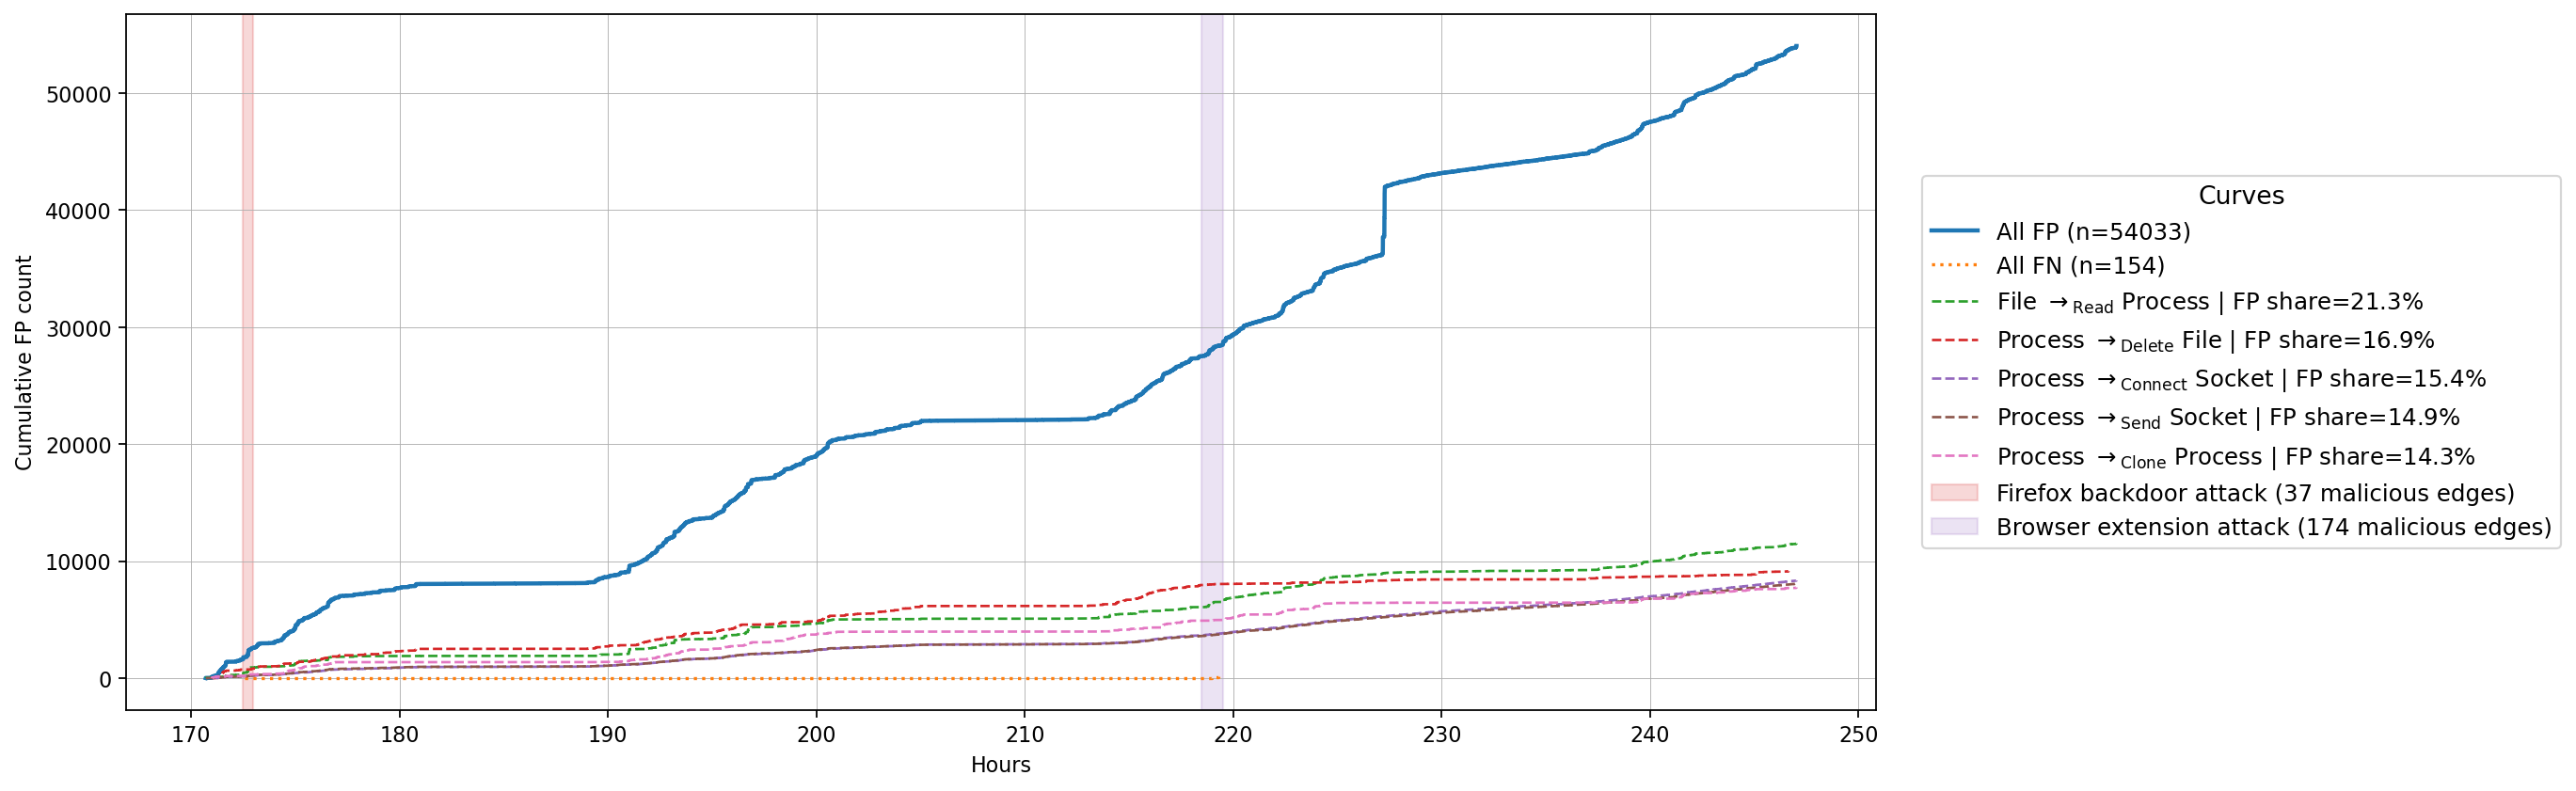

In [10]:
plot_fp_feature_cumulative(
    fp=fp,
    tn=tn,
    tp=tp,
    fn=fn,
    summary=summary_table,
    top_k=5,
    ranking_col='fp_share_of_all_fp',
    attack_events=attack_events,
    model_name=model_name,
    normalize=False,
    include_fn=True,
)

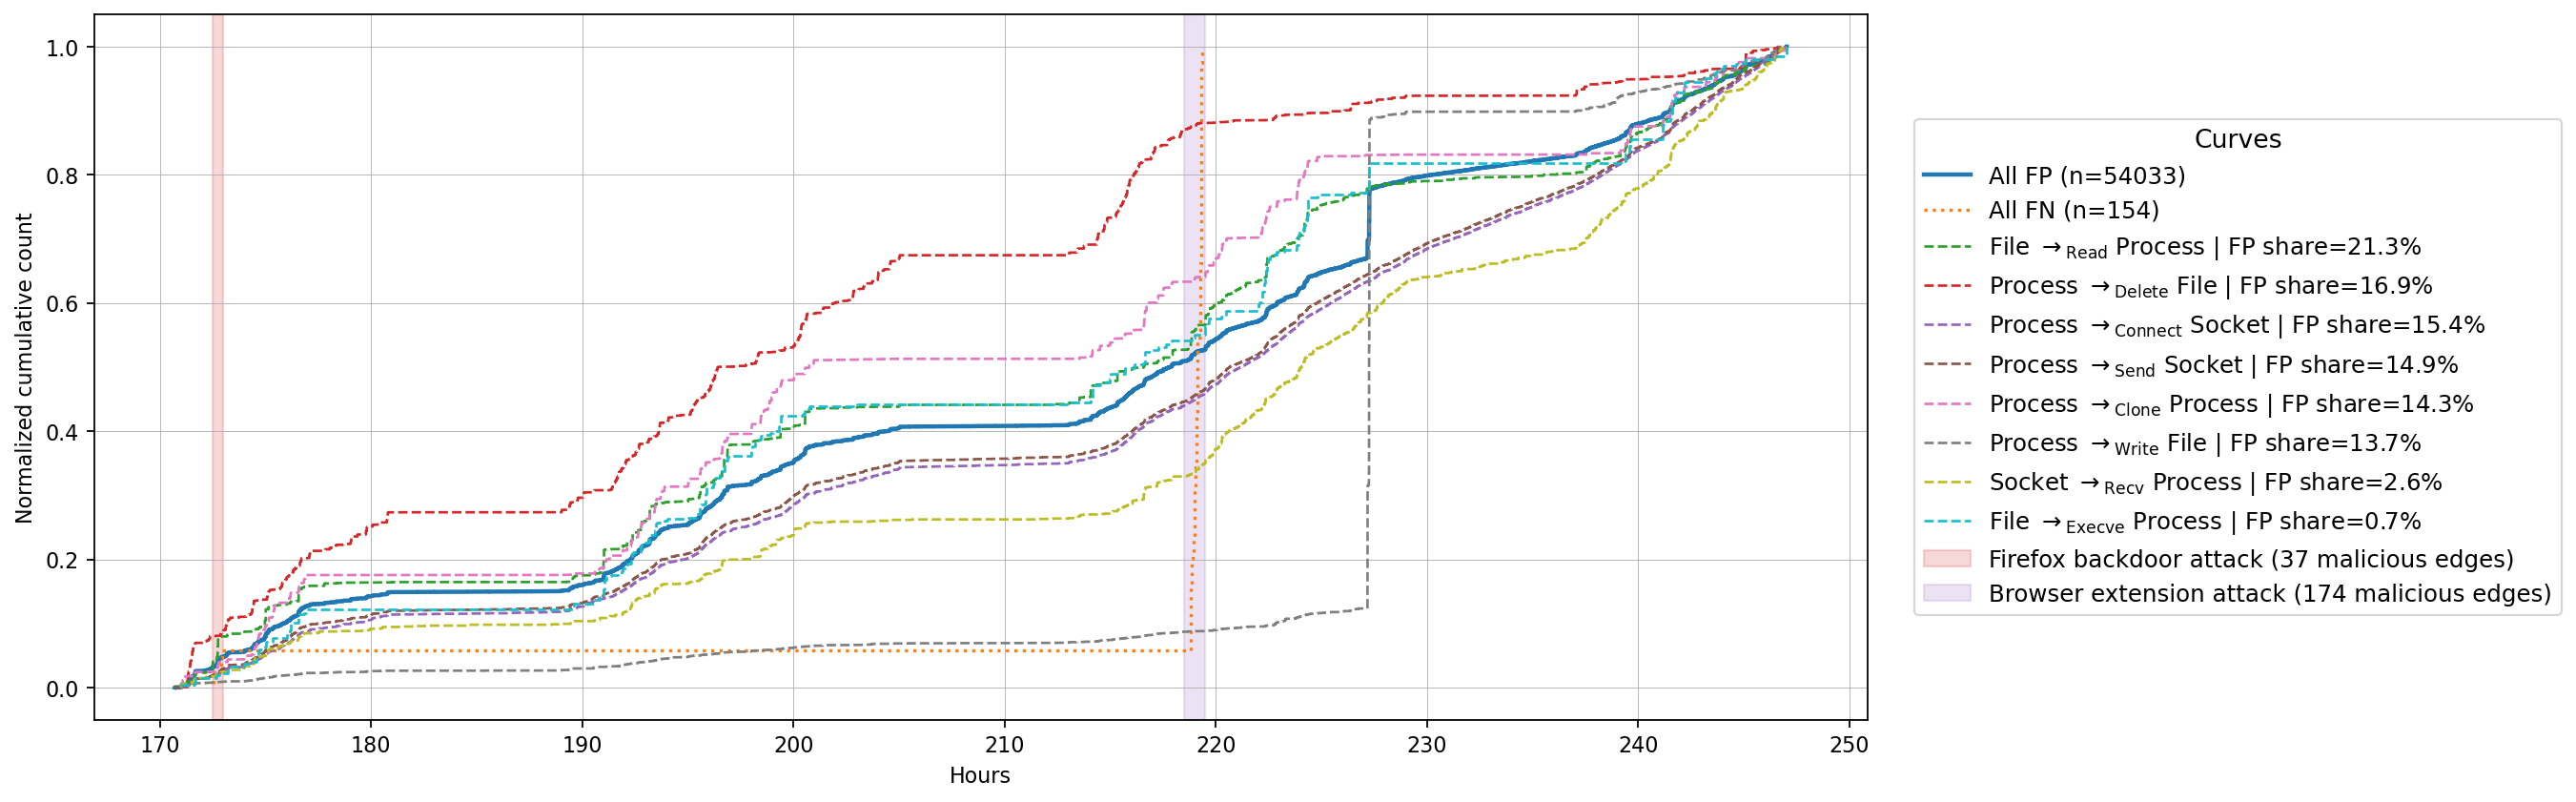

In [11]:
plot_fp_feature_cumulative(
    fp=fp,
    tn=tn,
    tp=tp,
    fn=fn,
    summary=summary_table,
    top_k=10,
    ranking_col='fp_share_of_all_fp',
    attack_events=attack_events,
    model_name=model_name,
    normalize=True,
    include_fn=True,
)

In [12]:
type_src = 0
type_dst = 1
syscall = 14   # file_process_read

def file_read_process_fp_in_window(
    fp,
    start_hour,
    end_hour,
    time_col="time",
    time_scale=3600000,
    min_count=1,
):
    # Convert time to hours
    fp_h = fp.copy()
    fp_h["hour"] = fp_h[time_col] / time_scale

    # Select the time window
    fp_w = fp_h[
        (fp_h["hour"] >= start_hour)
        & (fp_h["hour"] < end_hour)
    ].copy()

    # Select only File-read -> Process interaction
    # type_src=0: file
    # type_dst=1: process
    # syscall=14: read
    fp_read_proc = fp_w[
        (fp_w["type_src"] == 0)
        & (fp_w["type_dst"] == 1)
        & (fp_w["syscall"] == 14)
    ].copy()

    group_cols = ["root_src", "extension_src", "exe_dst"]

    table = (
        fp_read_proc
        .groupby(group_cols, dropna=False)
        .size()
        .reset_index(name="fp_count")
        .sort_values("fp_count", ascending=False)
    )

    table["fp_share_in_window_file_read_process"] = (
        table["fp_count"] / max(len(fp_read_proc), 1) * 100
    )

    table = table[table["fp_count"] >= min_count]

    print(f"Window: [{start_hour}, {end_hour}) hours")
    print(f"Total FP in window: {len(fp_w)}")
    print(f"File-read -> process FP in window: {len(fp_read_proc)}")

    return table.round(2)

In [13]:
file_read_peak = file_read_process_fp_in_window(
    fp=fp,
    start_hour=187.0,
    end_hour=190.0,
    min_count=1,
)

display(file_read_peak)

Window: [187.0, 190.0) hours
Total FP in window: 536
File-read -> process FP in window: 122


,root_src,extension_src,exe_dst,fp_count,fp_share_in_window_file_read_process
23,usr,pyc,sh,43,35.25
30,var,NaN,sh,16,13.11
22,usr,pth,sh,10,8.20
7,lib,15.so,firefox,9,7.38
10,lib,so.1,python,4,3.28
8,lib,15.so,sh,4,3.28
1,etc,cfg,python,4,3.28
16,proc,NaN,python,4,3.28
5,lib,15.so,apt-config,2,1.64
2,etc,conf,firefox,2,1.64


## Attack Insight: TP/FN Timing and Missed Attack Patterns

This section explains the sharp TP/FN cumulative jumps. It inspects malicious edges around the main attack windows and identifies which malicious edge types are detected versus missed.


In [14]:
def add_hour(df):
    df = df.copy()
    df['hour'] = (df.time / 3600000).astype(int)
    return df

fp_h = add_hour(fp)
tn_h = add_hour(tn)
tp_h = add_hour(tp)
fn_h = add_hour(fn)
train_h = add_hour(train)

attack_timing = pd.DataFrame({
    'split': ['TP', 'FN'],
    'count': [len(tp_h), len(fn_h)],
    'first_hour': [tp_h.time.min() / 3600000 if len(tp_h) else np.nan,
                   fn_h.time.min() / 3600000 if len(fn_h) else np.nan],
    'last_hour': [tp_h.time.max() / 3600000 if len(tp_h) else np.nan,
                  fn_h.time.max() / 3600000 if len(fn_h) else np.nan],
    'peak_hour': [tp_h.hour.value_counts().idxmax() if len(tp_h) else np.nan,
                  fn_h.hour.value_counts().idxmax() if len(fn_h) else np.nan],
    'peak_hour_count': [tp_h.hour.value_counts().max() if len(tp_h) else 0,
                        fn_h.hour.value_counts().max() if len(fn_h) else 0],
})
attack_timing


,split,count,first_hour,last_hour,peak_hour,peak_hour_count
0,TP,57,172.485736,219.327305,172,28
1,FN,154,172.554394,219.368949,219,109


In [15]:
def attack_group_summary(df, top=30):
    return (
        df.groupby(['hour', 'type_src', 'type_dst', 'syscall', 'exe_src', 'exe_dst'], dropna=False)
        .size()
        .sort_values(ascending=False)
        .head(top)
    )

ATTACK_JUMP_HOURS = [173, 219]
WINDOW = 1

for jump_hour in ATTACK_JUMP_HOURS:
    jump_tp = tp_h.loc[(tp_h.hour >= jump_hour - WINDOW) & (tp_h.hour <= jump_hour + WINDOW)].copy()
    jump_fn = fn_h.loc[(fn_h.hour >= jump_hour - WINDOW) & (fn_h.hour <= jump_hour + WINDOW)].copy()

    print('=' * 90)
    print(f'Window around {jump_hour}h: [{jump_hour-WINDOW}, {jump_hour+WINDOW}]h')
    print(f'TP in window: {len(jump_tp):,} / {len(tp):,} ({len(jump_tp) / max(len(tp), 1) * 100:.1f}%)')
    print(f'FN in window: {len(jump_fn):,} / {len(fn):,} ({len(jump_fn) / max(len(fn), 1) * 100:.1f}%)')

    print('\nTP groups around jump')
    display(attack_group_summary(jump_tp))
    print('\nFN groups around jump')
    display(attack_group_summary(jump_fn))


Window around 173h: [172, 174]h
TP in window: 28 / 57 (49.1%)
FN in window: 9 / 154 (5.8%)

TP groups around jump


hour  type_src  type_dst  syscall  exe_src  exe_dst
172   1         2         9        clean    NaN        17
                                   profile  NaN         5
                0         15       firefox  NaN         2
      2         1         8        NaN      firefox     2
      1         2         16       clean    NaN         1
                                   profile  NaN         1
dtype: int64


FN groups around jump


hour  type_src  type_dst  syscall  exe_src  exe_dst
172   2         1         8        NaN      profile    2
                                            clean      2
      0         1         3        NaN      clean      1
                          14       NaN      clean      1
                          3        NaN      profile    1
      1         0         15       profile  NaN        1
      0         1         14       NaN      profile    1
dtype: int64

Window around 219h: [218, 220]h
TP in window: 29 / 57 (50.9%)
FN in window: 145 / 154 (94.2%)

TP groups around jump


hour  type_src  type_dst  syscall  exe_src  exe_dst
218   1         2         9        gtcache  NaN        16
219   1         2         16       mail     NaN         4
218   0         1         14       NaN      gtcache     2
      1         2         9        firefox  NaN         1
                          16       firefox  NaN         1
                          9        sh       NaN         1
                          16       sh       NaN         1
      2         1         8        NaN      firefox     1
                                            sh          1
219   1         2         9        mail     NaN         1
dtype: int64


FN groups around jump


hour  type_src  type_dst  syscall  exe_src   exe_dst 
219   2         1         8        NaN       mail        24
      1         2         9        mail      NaN         23
                          16       mail      NaN         20
218   1         1         2        sh        gtcache     19
219   1         2         9        gtcache   NaN         15
                1         2        sh        gtcache     15
                0         15       gtcache   NaN          5
218   0         1         14       NaN       gtcache      3
219   1         2         16       gtcache   NaN          3
218   1         1         2        pass_mgr  sh           2
                0         15       gtcache   NaN          2
                2         9        gtcache   NaN          2
      0         1         3        NaN       pass_mgr     1
                                             sh           1
      1         0         6        gtcache   NaN          1
      0         1         14       NaN       p

In [16]:
# Compare all detected vs missed malicious edge patterns, regardless of hour.
tp_attack_counts = tp.groupby(columns_to_group, dropna=False).size()
fn_attack_counts = fn.groupby(columns_to_group, dropna=False).size()

attack_view = pd.DataFrame({
    'tp_count': tp_attack_counts,
    'fn_count': fn_attack_counts,
}).fillna(0)

attack_view['mal_count'] = attack_view.tp_count + attack_view.fn_count
attack_view['tp_pct_of_mal_pattern'] = attack_view.tp_count / attack_view.mal_count.replace(0, np.nan) * 100
attack_view['fn_pct_of_mal_pattern'] = attack_view.fn_count / attack_view.mal_count.replace(0, np.nan) * 100
attack_view['tp_pct_all_tp'] = attack_view.tp_count / max(len(tp), 1) * 100
attack_view['fn_pct_all_fn'] = attack_view.fn_count / max(len(fn), 1) * 100

attack_view.sort_values('mal_count', ascending=False).head(30).round(2)


tp_count  fn_count  mal_count  \
type_src type_dst syscall                                  
1        2        9            41.0        41       82.0   
         1        2             0.0        37       37.0   
2        1        8             4.0        29       33.0   
1        2        16            8.0        24       32.0   
         0        15            2.0        10       12.0   
0        1        14            2.0         6        8.0   
                  3             0.0         5        5.0   
1        0        6             0.0         2        2.0   

                           tp_pct_of_mal_pattern  fn_pct_of_mal_pattern  \
type_src type_dst syscall                                                 
1        2        9                        50.00                  50.00   
         1        2                         0.00                 100.00   
2        1        8                        12.12                  87.88   
1        2        16                       25.00                  75.00   
         0        15                       16.67                  83.33   
0        1        14                       25.00                  75.00   
                  3                         0.00                 100.00   
1        0        6                         0.00                 100.00   

                           tp_pct_all_tp  fn_pct_all_fn  
type_src type_dst syscall                                
1        2        9                71.93          26.62  
         1        2                 0.00          24.03  
2        1        8                 7.02          18.83  
1        2        16               14.04          15.58  
         0        15                3.51           6.49  
0        1        14                3.51           3.90  
                  3                 0.00           3.25  
1        0        6                 0.00           1.30

In [17]:
# Attack executable involvement: which executables dominate detected and missed malicious edges?
def exe_involvement(df):
    src = df.exe_src.dropna().rename('exe')
    dst = df.exe_dst.dropna().rename('exe')
    return pd.concat([src, dst]).value_counts()

tp_exe = exe_involvement(tp).rename('tp_count')
fn_exe = exe_involvement(fn).rename('fn_count')

attack_exe_view = pd.concat([tp_exe, fn_exe], axis=1).fillna(0)
attack_exe_view['total_malicious_involvement'] = attack_exe_view.tp_count + attack_exe_view.fn_count
attack_exe_view['fn_share'] = attack_exe_view.fn_count / attack_exe_view.total_malicious_involvement.replace(0, np.nan) * 100
attack_exe_view.sort_values('total_malicious_involvement', ascending=False).head(30).round(2)


,tp_count,fn_count,total_malicious_involvement,fn_share
exe,,,,
gtcache,18.0,68,86.0,79.07
mail,5.0,68,73.0,93.15
sh,3.0,37,40.0,92.50
clean,18.0,4,22.0,18.18
profile,6.0,8,14.0,57.14
firefox,7.0,2,9.0,22.22
pass_mgr,0.0,4,4.0,100.00


## Attack-Level Score Check

This checks whether each ground-truth attack has at least a few correctly detected edges (`TP`) with high anomaly scores compared with the full test set. Here `anomaly_score = 1 - prob`, because this notebook marks anomalous predictions with lower model `prob`.


In [18]:
attack_definitions = {
    'firefox_backdoor': GROUND_TRUTH_DIR / 'TC3_theia_firefox_backdoor_final_aggregated.csv',
    'browser_extension': GROUND_TRUTH_DIR / 'TC3_theia_browser_extension_final_aggregated.csv',
}

attack_by_hash = {}
for attack_name, attack_path in attack_definitions.items():
    attack_df = pd.read_csv(attack_path)
    for h in attack_df.edge_hash_id.astype(str):
        attack_by_hash[h] = attack_name if h not in attack_by_hash else attack_by_hash[h] + '+' + attack_name

test_scores = edges.loc[test_index, ['hash_id', 'time', 'malicious']].copy()
test_scores.loc[:, 'prob'] = aggregated_predictions
test_scores.loc[:, 'anomaly_score'] = 1 - test_scores['prob']
test_scores.loc[:, 'pred_anomalous'] = pred_anomalous_values
test_scores.loc[:, 'hour'] = test_scores.time / 3600000
test_scores.loc[:, 'attack'] = test_scores.hash_id.astype(str).map(attack_by_hash).fillna('benign')

test_scores.loc[:, 'outcome'] = np.select(
    [
        test_scores.malicious & test_scores.pred_anomalous,
        (~test_scores.malicious) & test_scores.pred_anomalous,
        test_scores.malicious & (~test_scores.pred_anomalous),
        (~test_scores.malicious) & (~test_scores.pred_anomalous),
    ],
    ['TP', 'FP', 'FN', 'TN'],
    default='unknown',
)

all_scores_sorted = np.sort(test_scores.anomaly_score.to_numpy())
test_scores.loc[:, 'score_percentile'] = (
    np.searchsorted(all_scores_sorted, test_scores.anomaly_score.to_numpy(), side='right')
    / len(all_scores_sorted)
    * 100
)

top_1_threshold = np.quantile(test_scores.anomaly_score, 0.99)
top_01_threshold = np.quantile(test_scores.anomaly_score, 0.999)

def attack_score_summary(group):
    tp_group = group[group.outcome == 'TP']
    fn_group = group[group.outcome == 'FN']
    return pd.Series({
        'malicious_edges': len(group),
        'tp_count': len(tp_group),
        'fn_count': len(fn_group),
        'tp_rate_pct': len(tp_group) / max(len(group), 1) * 100,
        'tp_in_top_1pct': int((tp_group.anomaly_score >= top_1_threshold).sum()),
        'tp_in_top_0_1pct': int((tp_group.anomaly_score >= top_01_threshold).sum()),
        'best_tp_score_percentile': tp_group.score_percentile.max() if len(tp_group) else np.nan,
        'median_tp_score_percentile': tp_group.score_percentile.median() if len(tp_group) else np.nan,
        'best_fn_score_percentile': fn_group.score_percentile.max() if len(fn_group) else np.nan,
        'median_fn_score_percentile': fn_group.score_percentile.median() if len(fn_group) else np.nan,
    })

attack_scores_summary = (
    test_scores[test_scores.attack != 'benign']
    .groupby('attack', dropna=False)
    .apply(attack_score_summary)
    .sort_values('malicious_edges', ascending=False)
)

attack_scores_summary.round(2)


,malicious_edges,tp_count,fn_count,tp_rate_pct,tp_in_top_1pct,tp_in_top_0_1pct,best_tp_score_percentile,median_tp_score_percentile,best_fn_score_percentile,median_fn_score_percentile
attack,,,,,,,,,,
browser_extension,174.0,29.0,145.0,16.67,26.0,0.0,99.82,99.60,98.75,92.89
firefox_backdoor,37.0,28.0,9.0,75.68,28.0,0.0,99.75,99.63,97.14,94.66


In [19]:
score_col = "anomaly_score"   # change this if your actual score column has another name

# First, keep only true-positive attack edges
attack_tp = test_scores[
    (test_scores["attack"] != "benign")
].copy()

# Aggregate scores per attack edge / hash_id
attack_tp_edge_scores = (
    attack_tp
    .groupby(["attack", "hash_id"], dropna=False)
    .agg(
        max_score=(score_col, "max"),
        min_score=(score_col, "min"),
        median_score=(score_col, "median"),
    )
    .reset_index()
)

# Then summarize per attack
attack_score_answer = (
    attack_tp_edge_scores
    .groupby("attack", dropna=False)
    .agg(
        tp_count=("hash_id", "size"),
        max_score=("max_score", "max"),
        min_score=("min_score", "min"),
        median_score=("median_score", "median"),
    )
    .sort_values("max_score", ascending=False)
)

attack_score_answer.round(2)

,tp_count,max_score,min_score,median_score
attack,,,,
browser_extension,174,0.99,0.00,0.15
firefox_backdoor,37,0.92,0.01,0.84


## Extra Diagnostic: Prediction Confidence

This checks whether false positives are borderline decisions or high-confidence mistakes. It is useful for comparing models: M2 may reduce FP count, but if remaining FPs are still high-confidence, the failure mode remains important.

In [20]:
# Attach averaged prediction probabilities to each split.
# In this project, anomalous predictions are selected with `~aggregated_predictions.round().astype(bool)`,
# so lower `prob` means more anomalous, and `anomaly_score = 1 - prob` is easier to read.
prob_by_edge_index = pd.Series(aggregated_predictions, index=test_index, name='prob')

for df in [fp, tn, tp, fn]:
    if 'prob' not in df.columns:
        df.loc[:, 'prob'] = df.edge_index.map(prob_by_edge_index)
        df.loc[:, 'anomaly_score'] = 1 - df['prob']

score_summary = pd.DataFrame({
    'split': ['TP', 'FP', 'FN', 'TN'],
    'n': [len(tp), len(fp), len(fn), len(tn)],
    'prob_mean': [tp.prob.mean(), fp.prob.mean(), fn.prob.mean(), tn.prob.mean()],
    'prob_median': [tp.prob.median(), fp.prob.median(), fn.prob.median(), tn.prob.median()],
    'anomaly_score_mean': [tp.anomaly_score.mean(), fp.anomaly_score.mean(), fn.anomaly_score.mean(), tn.anomaly_score.mean()],
    'anomaly_score_median': [tp.anomaly_score.median(), fp.anomaly_score.median(), fn.anomaly_score.median(), tn.anomaly_score.median()],
})
score_summary.round(4)


,split,n,prob_mean,prob_median,anomaly_score_mean,anomaly_score_median
0,TP,57,0.1949,0.1401,0.8051,0.8599
1,FP,54033,0.2472,0.2685,0.7528,0.7315
2,FN,154,0.8532,0.9221,0.1468,0.0779
3,TN,4619493,0.9770,0.9992,0.0230,0.0008
